In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pgeocode
from sklearn.impute import KNNImputer


In [2]:
path = r"C:\Users\13926\Downloads\DDAI\Atlantic\florida_real_estate_sold_properties_ultimate.csv"
df = pd.read_csv(path)
df.head()

,type,sub_type,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,zip,sanitized_text
0,single_family,NaN,630000.0,605000,2274.0,1.0,2.0,3.0,2.0,2.0,2.0,2007.0,33446.0,"Beautiful 2 Bedroom + Den, 2.5 Bath Home - Mov..."
1,single_family,NaN,289000.0,285000,2170.0,1.0,3.0,2.0,2.0,2.0,2.0,1980.0,33876.0,Welcome to Florida living at its best! This 3-...
2,condos,condo,449000.0,425000,1722.0,NaN,3.0,2.0,2.0,2.0,2.0,2016.0,33913.0,Best Value in Casella and priced to sell... St...
3,single_family,NaN,599000.0,596000,1699.0,1.0,3.0,3.0,3.0,3.0,NaN,1952.0,33009.0,"Beautifully renovated 3-bedroom, 3-bathroom ho..."
4,single_family,NaN,173500.0,165000,640.0,1.0,1.0,1.0,1.0,1.0,NaN,1971.0,32118.0,Experience the ultimate beachfront lifestyle i...


In [3]:
df.shape

(10893, 14)

In [4]:
df_clean = df.drop_duplicates().copy()
df_clean = df_clean.drop(columns=['listPrice', 'baths_full_calc', 'sanitized_text'])
cols_to_check = df_clean.columns[df_clean.isna().sum() > 0]
len(cols_to_check)
display(df_clean.shape)

(10872, 11)

In [5]:
df_clean.isna().sum()

type                0
sub_type         8403
lastSoldPrice       0
sqft              748
stories          1719
beds              667
baths             631
baths_full        674
garage           3576
year_built        669
zip                 2
dtype: int64

In [6]:
(df_clean.isna().sum() / len(df_clean)).round(3)

type             0.000
sub_type         0.773
lastSoldPrice    0.000
sqft             0.069
stories          0.158
beds             0.061
baths            0.058
baths_full       0.062
garage           0.329
year_built       0.062
zip              0.000
dtype: float64

In [7]:
df_clean['garage'].value_counts(dropna=False)


garage
2.0     4851
NaN     3576
1.0     1523
3.0      810
4.0       78
6.0       16
5.0       11
8.0        4
16.0       1
7.0        1
12.0       1
Name: count, dtype: int64

In [8]:
df_clean.dtypes

type                 str
sub_type             str
lastSoldPrice      int64
sqft             float64
stories          float64
beds             float64
baths            float64
baths_full       float64
garage           float64
year_built       float64
zip              float64
dtype: object

In [21]:
knn_imputer = KNNImputer(n_neighbors=5)
df_clean2 = df_clean.drop(columns=['sub_type'])
df_clean2 = df_clean2.dropna(subset=['zip'])

df_clean2['garage'] = df_clean2['garage'].fillna(0)


In [23]:
df_clean2['stories'] = df_clean2.groupby('type')['stories'].transform(lambda x: x.fillna(x.median()))
# The entire 'type' group of 'land' has no missing 'stories' values at all, so we have to fill the null values again with the median of the whole class
df_clean2['stories'] = df_clean2['stories'].fillna(df_clean2['stories'].median())
df_num = df_clean2.select_dtypes(include='number')
df_cat = df_clean2.select_dtypes(exclude='number')
df_num_imputed = pd.DataFrame(knn_imputer.fit_transform(df_num), columns=df_num.columns, index=df_clean2.index)
df_clean2 = pd.concat([df_cat, df_num_imputed], axis=1)

In [ ]:
# df_clean2.groupby('type')['stories'].apply(lambda x: x.isna().sum())
# df_clean2.groupby('type')['stories'].count()
# df_clean2['stories'] = df_clean2.groupby('type')['stories'].transform(lambda x: x.fillna(x.median()))


In [24]:
df_clean2.isna().sum()


type             0
lastSoldPrice    0
sqft             0
stories          0
beds             0
baths            0
baths_full       0
garage           0
year_built       0
zip              0
dtype: int64

In [25]:
df_clean3 = df_clean2.copy()
df_clean3['age'] = 2026 - df_clean3['year_built']
df_clean3.drop(columns=['year_built'], inplace=True)
df_clean3['age'].head(20)

0     19.0
1     46.0
2     10.0
3     74.0
4     55.0
5     19.0
6     19.0
7     14.0
8     66.0
9      1.0
10    41.0
11     3.0
12    27.0
13    35.0
14    21.0
15     1.0
16     7.0
17    12.0
18     2.0
19    38.0
Name: age, dtype: float64

It's worth noting that the column [zip] doesn't have any meaningful meaning yet.


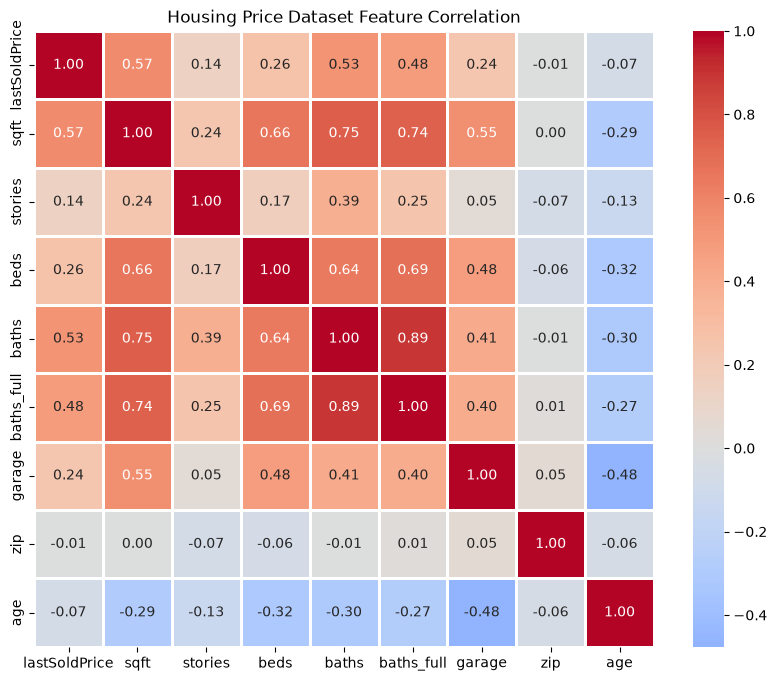

In [26]:
num_df = df_clean3.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(),
            cmap='coolwarm',
            fmt='.2f',
            center=0,
            linewidths=2,
            annot=True)
plt.title('Housing Price Dataset Feature Correlation')
print("It's worth noting that the column [zip] doesn't have any meaningful meaning yet.")

In [27]:
# Test pgeocode query result
nomi = pgeocode.Nominatim('us')
nomi.query_postal_code('75080')

postal_code            75080
country_code              US
place_name        Richardson
state_name             Texas
state_code                TX
county_name           Dallas
county_code            113.0
community_name           NaN
community_code           NaN
latitude              32.966
longitude           -96.7452
accuracy                 4.0
Name: 0, dtype: object

In [28]:
# Create a dataframe containing the query results for every zip in the data frame
df_with_coords = df_clean3.copy()
zip_list = df_with_coords['zip'].astype(int).astype(str).str.zfill(5).tolist()
zip_coords = nomi.query_postal_code(zip_list)
print(df_with_coords.shape, zip_coords.shape)

(10870, 10) (10870, 12)


In [29]:
df_with_coords['lat'] = zip_coords['latitude'].values
df_with_coords['long'] = zip_coords['longitude'].values
df_with_coords = df_with_coords.drop(columns='zip')
df_with_coords.head()

,type,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,age,lat,long
0,single_family,605000.0,2274.0,1.0,2.0,3.0,2.0,2.0,19.0,26.4517,-80.1580
1,single_family,285000.0,2170.0,1.0,3.0,2.0,2.0,2.0,46.0,27.4287,-81.3519
2,condos,425000.0,1722.0,1.0,3.0,2.0,2.0,2.0,10.0,26.5228,-81.7065
3,single_family,596000.0,1699.0,1.0,3.0,3.0,3.0,0.0,74.0,25.9850,-80.1407
4,single_family,165000.0,640.0,1.0,1.0,1.0,1.0,0.0,55.0,29.2219,-81.0095


Text(0.5, 1.0, 'Housing Price Dataset Feature Correlation')

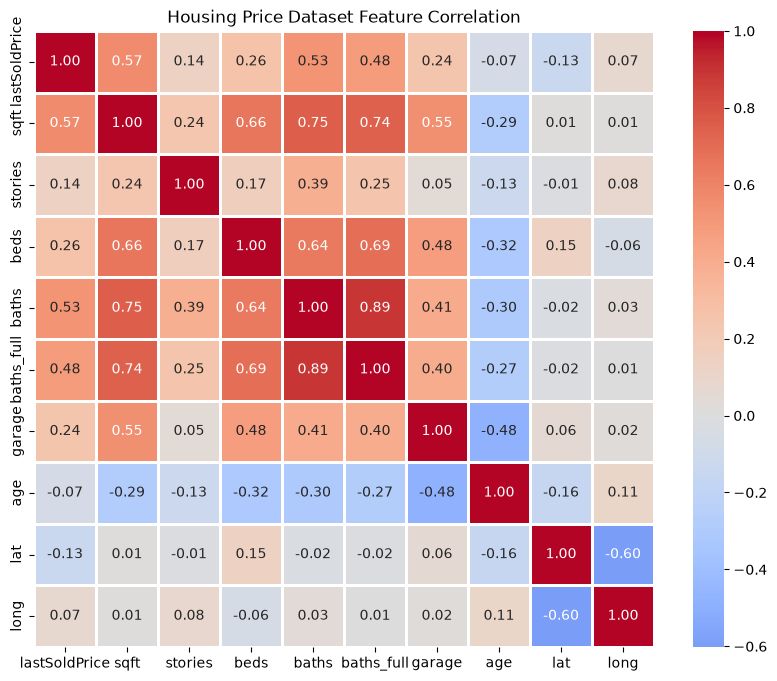

In [30]:
# Heatmap of correlation to see what changed after converting zip to lat and long
num_df_coords = df_with_coords.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(num_df_coords.corr(),
            cmap='coolwarm',
            fmt='.2f',
            center=0,
            linewidths=2,
            annot=True)
plt.title('Housing Price Dataset Feature Correlation')

Text(0.5, 1.0, 'Relationships between Area and Price')

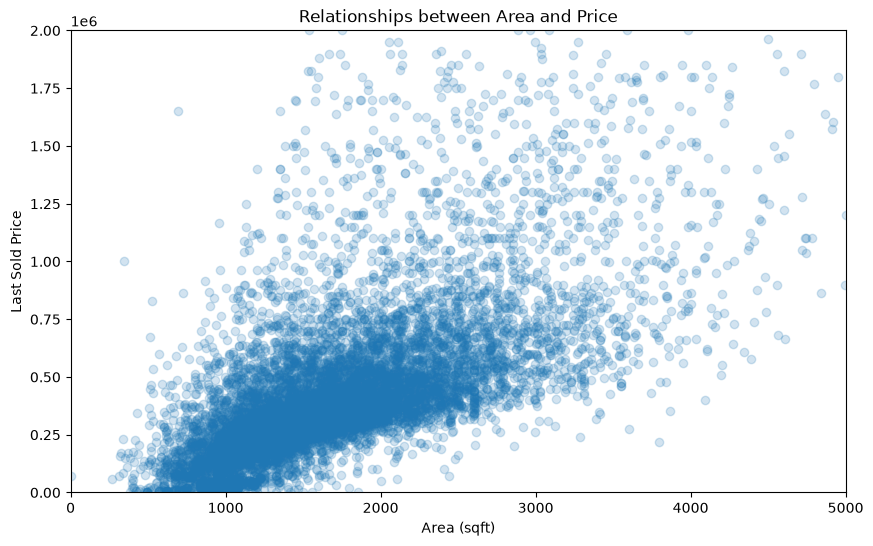

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df_with_coords['sqft'], df_with_coords['lastSoldPrice'], alpha=0.2)
plt.xlabel('Area (sqft)')
plt.ylabel('Last Sold Price')
plt.xlim(0, 5000)
plt.ylim(0.0, 0.2* 1e7)
plt.title('Relationships between Area and Price')

In [32]:
df_with_coords['lastSoldPrice'].describe()

count    1.087000e+04
mean     5.582996e+05
std      1.145331e+06
min      1.000000e+01
25%      2.550000e+05
50%      3.650000e+05
75%      5.586800e+05
max      5.166718e+07
Name: lastSoldPrice, dtype: float64

In [33]:
df_with_coords.to_csv("florida_real_estate_clean.csv", index=False)

In [ ]:
# Still need encoding and scaling before training